# METHOD: build a classification model

# AIM: Genetic features to predict clinical benefits

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold
import sys

In [2]:
import sklearn
print(sklearn.__version__)

1.3.2


In [3]:
import warnings
# Suppress all FutureWarnings
warnings.filterwarnings("ignore", category=FutureWarning)


# select genes based on gene expression values

In [4]:
genetic = pd.read_csv("Expression_log2_21_primaryNivo_braun_2020.csv",index_col=0)
genetic

,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2MP1,A3GALT2,A4GALT,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
gene_name,,,,,,,,,,,,,,,,,,,,,
G138701_RCCBMS-00020-T_v1_RNA_OnPrem,30.187983,22.999432,33.643965,37.130851,22.705126,22.869853,21.076515,21.271282,21.807184,33.279532,...,33.26816,30.04056,30.36292,30.98129,32.38442,28.01561,31.24379,33.81903,33.22469,31.23383
G138701_RCCBMS-00097-T_v1_RNA_OnPrem,30.483638,25.581769,28.866645,37.945043,27.797609,24.142100,21.076515,21.271282,21.807184,33.019435,...,31.53633,29.94062,30.80829,30.74475,32.09470,26.32526,32.70057,33.67262,33.10198,32.44643
G138701_RCCBMS-00141-T_v1_RNA_OnPrem,30.092851,26.933385,26.684228,36.851946,22.705126,30.406352,21.076515,21.271282,21.807184,31.033210,...,30.74474,31.95812,30.73898,30.15898,31.69473,26.33098,32.68330,33.96047,32.97135,32.20607
G138701_RCCBMS-00099-T_v1_RNA_OnPrem,30.975010,26.683128,32.521494,38.453517,26.337846,28.229357,21.076515,21.271282,26.484608,33.009203,...,31.63196,30.71732,31.09654,30.25757,31.90774,27.53819,32.64194,34.54254,33.24885,32.78278
G138701_RCCBMS-00163-T_v1_RNA_OnPrem,26.915750,22.999432,23.219176,38.931987,22.705126,22.869853,21.076515,21.271282,21.807184,31.447751,...,31.75620,30.75149,30.55896,30.17101,31.01545,21.45312,32.86620,34.24375,34.86720,32.73361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
P66507-04D-Run1_S3_L001,29.718678,21.286965,33.059162,35.566022,21.357557,27.686244,20.980667,25.034267,21.018133,33.704298,...,28.60179,30.27215,31.08287,31.21266,33.18573,29.26041,31.70839,32.97611,34.23396,32.87393
P66507-07G-Run1_S17_L002,31.147910,21.286965,31.617351,37.423994,21.357557,27.720569,20.980667,20.992693,28.011280,35.638479,...,26.14211,31.31652,31.24066,31.34713,33.06662,27.08693,30.62278,35.10264,33.68084,30.73622
P66425-03B-Run1_S10_L001,30.099518,25.040893,33.891608,38.289830,21.357557,26.870362,20.980667,20.992693,21.018133,33.654328,...,32.54706,29.97152,31.22229,30.38211,31.30604,27.29504,32.44263,34.20699,32.80918,32.29759


In [5]:
cl = pd.read_csv("braun_data_clinical_data.csv",index_col=0)
dfcl = cl.loc[genetic.index,:][cl["Benefit"].isin(["CB","NCB"])]

/tmp/ipykernel_527286/3204985976.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dfcl = cl.loc[genetic.index,:][cl["Benefit"].isin(["CB","NCB"])]


In [6]:
dfmerge = pd.merge(genetic.reset_index(),cl.reset_index(),how='left', left_on="gene_name", right_on="RNA_ID")
dfmerge.shape

(133, 20561)

In [7]:
modelinput_expr = genetic.loc[dfcl.index.tolist()]
print(modelinput_expr.shape)
modeltarget_expr = dfcl["Benefit"].replace("NCB",0).replace("CB",1).tolist()

(90, 20545)


In [8]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

from sklearn.preprocessing import OneHotEncoder
from sklearn import datasets, linear_model
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import  LogisticRegression, SGDClassifier
from sklearn import metrics
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.metrics import RocCurveDisplay

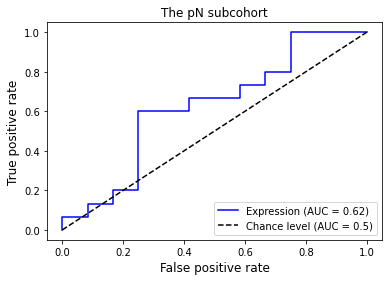

lr准确率： 0.6296296296296297
lr的其他指标：
               precision    recall  f1-score   support

          CB       0.69      0.60      0.64        15
         NCB       0.57      0.67      0.62        12

    accuracy                           0.63        27
   macro avg       0.63      0.63      0.63        27
weighted avg       0.64      0.63      0.63        27



In [9]:
X_train, X_test, y_train, y_test = train_test_split(modelinput_expr, 
                                                     dfcl["Benefit"],
                                                   test_size=0.3,random_state=0)

base_model = LogisticRegression(penalty='l2', C=1, max_iter=1000, random_state=42, class_weight='balanced')

# Combine feature selection and model into a pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),  
    ('feature_selection', SelectKBest( k=20)),
    ('logistic_regression', base_model)
])

# Fit the pipeline on training data
pipeline.fit(X_train, y_train)

lr_y_predict = pipeline.predict(X_test)

#fig, ax = plt.subplots() 
RocCurveDisplay.from_estimator(pipeline,X_test, y_test,pos_label="CB",plot_chance_level=True,name=f"Expression",c="blue")
plt.title('The pN subcohort',fontsize=12)
plt.ylabel("True positive rate",fontsize=12)
plt.xlabel("False positive rate",fontsize=12)
#plt.savefig(f"expression_AUC.svg",dpi=600,bbox_inches='tight')
plt.show()

print("lr准确率：", pipeline.score(X_test, y_test))
print("lr的其他指标：\n", classification_report(y_test, lr_y_predict, target_names=["CB", "NCB"],zero_division=0.0))


In [9]:
X = modelinput_expr.copy()
y = dfcl["Benefit"].copy()

In [10]:
X.shape

(90, 20545)

# K = 20

In [29]:
# Combine feature selection and model into a pipeline
from sklearn.model_selection import cross_val_score

cv_score =[]

for i in range(1,100):

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('feature_selection',  SelectKBest(f_classif, k=i*10)),
        ('logistic_regression', LogisticRegression(penalty='l2',  C=1,max_iter=1000, random_state=42,class_weight ='balanced')),
    ])


    scores = cross_val_score(pipeline ,X\
                             , dfcl["Benefit"], cv=5,scoring='accuracy',)
    cv_score.append(scores)

0.6333333333333334


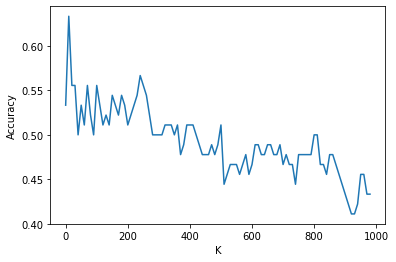

In [33]:
import matplotlib.pyplot as plt
print(np.max([cv_score[i-1].mean() for i in range(1,99)]))
plt.plot([i*10 for i in range(0,99)],[ i.mean() for i in cv_score])
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.savefig("gene_expression_ML-LR_K.svg",dpi=300)

In [12]:
# Spot Check Algorithms
# edges_input


from sklearn.model_selection import LeaveOneOut
for datetype,dataname in \
    zip([ modelinput_expr.copy()],\
        ["expression"]):
            
    models = []
    models.append(('LR',LogisticRegression(penalty='l2',  C=1,max_iter=1000, random_state=42,class_weight ='balanced')))
    results = []
    names = []
    for name, model in models:
        # Define leave-one-out cross-validation
        loo = LeaveOneOut()

        for i in range(1,11):
                    # Evaluate the pipeline with LOOCV
            scores = []
            y_resonse = []
            y_pred_list = []
            for train_index, test_index in loo.split(datetype):
                # Create a pipeline
                pipeline = Pipeline([
                    ('scaler', StandardScaler()),
                    ('feature_selection', SelectKBest(score_func=f_classif,k=i*10)), 
                    ('logistic_regression', model)       # Logistic Regression model
            ])
                # Split data into train and test for this fold
                X_train, X_test = datetype.iloc[train_index], datetype.iloc[test_index]
                y_train, y_test = dfcl["Benefit"][train_index], dfcl["Benefit"][test_index]
                
                # Fit the pipeline on the training data
                pipeline.fit(X_train, y_train)
                
                # Predict on the test data
                y_pred = pipeline.predict(X_test)
                y_resonse.append(y_test)
                y_pred_list.append(y_pred)
                # Store the accuracy for this fold
                scores.append(accuracy_score(y_test, y_pred))  
                #print(scores)
            results.append(sum(scores)/len(scores))
            names.append(name)
            print(name, sum(scores)/len(scores))
        

LR 0.7
LR 0.6111111111111112
LR 0.6111111111111112
LR 0.6333333333333333
LR 0.6222222222222222
LR 0.5666666666666667
LR 0.4777777777777778
LR 0.5
LR 0.5222222222222223
LR 0.5333333333333333


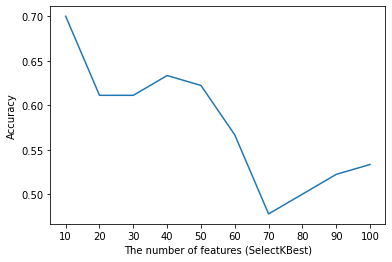

In [18]:
import matplotlib.pyplot as plt

plt.plot(range(10, 101, 10),results)
plt.xticks(range(10, 101, 10))
plt.xlabel("The number of features (SelectKBest)")
plt.ylabel("Accuracy")
plt.savefig("gene_expression_ML-LR_K.svg",dpi=300)

## Different selectors

In [ ]:
# SFS

from sklearn.model_selection import LeaveOneOut
for datetype,dataname in \
    zip([ modelinput_expr.copy()],\
        ["expression"]):
            
    models = []
    models.append(('LR',LogisticRegression(penalty='l2', C=1, max_iter=1000, random_state=42,class_weight ='balanced')))
    results = []
    names = []
    for name, model in models:
        # Define leave-one-out cross-validation
        loo = LeaveOneOut()
        # Evaluate the pipeline with LOOCV
        scores = []
        y_resonse = []
        y_pred_list = []
        
        for train_index, test_index in loo.split(datetype):
            print(test_index)
            # Split data into train and test for this fold
            X_train, X_test = datetype.iloc[train_index], datetype.iloc[test_index]
            y_train, y_test = dfcl["Benefit"][train_index], dfcl["Benefit"][test_index]
            # Create a pipeline
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('feature_selection', SelectKBest(score_func=f_classif,k=100)), 
                ('SequentialFeatureSelector', SequentialFeatureSelector(base_model, n_features_to_select='auto', 
                                    direction='forward', cv=5, n_jobs=-1)),
                ('logistic_regression', model)       # Logistic Regression model
        ])
        

            # Fit the pipeline on the training data
            pipeline.fit(X_train, y_train)
            
            # Predict on the test data
            y_pred = pipeline.predict(X_test)
            
            y_resonse.append(y_test)
            y_pred_list.append(y_pred)
            # Store the accuracy for this fold
            scores.append(accuracy_score(y_test, y_pred))  
            #print(scores)
        results.append(sum(scores)/len(scores))
        names.append(name)
        print(name, sum(scores)/len(scores))
        

In [ ]:
# Hyperparameter

from sklearn.model_selection import LeaveOneOut
for datetype,dataname in \
    zip([ modelinput_expr.copy()],\
        ["expression"]):
            
    models = []
    models.append(('LR',LogisticRegression(penalty='l2', C=1, max_iter=1000, random_state=42,class_weight ='balanced')))
    results = []
    names = []
    for name, model in models:
        # Define leave-one-out cross-validation
        loo = LeaveOneOut()
        # Evaluate the pipeline with LOOCV
        scores = []
        y_resonse = []
        y_pred_list = []
        
        for train_index, test_index in loo.split(datetype):
            print(test_index)
            # Split data into train and test for this fold
            X_train, X_test = datetype.iloc[train_index], datetype.iloc[test_index]
            y_train, y_test = dfcl["Benefit"][train_index], dfcl["Benefit"][test_index]
            # Create a pipeline
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('feature_selection', SelectKBest(score_func=f_classif)), 
                ('logistic_regression', model)       # Logistic Regression model
        ])
        
            # Define parameter grid for GridSearchCV
            param_grid = {
                'feature_selection__k': [num*10 for num in range(1,10)],  # Number of features to select
                #'logistic_regression__C': [num/10 for num in range(1,11)]  # Regularization parameter
            }
    
            # Apply GridSearchCV on training data
            grid_search = GridSearchCV(
                estimator=pipeline,
                param_grid=param_grid,
                scoring='accuracy',
                cv=5,  # Perform internal k-fold CV on the training set
                n_jobs=-1
            )
            grid_search.fit(X_train, y_train)

            best_pipeline = grid_search.best_estimator_
            y_pred = best_pipeline.predict(X_test)
            
            y_resonse.append(y_test)
            y_pred_list.append(y_pred)
            # Store the accuracy for this fold
            scores.append(accuracy_score(y_test, y_pred))  
            #print(scores)
        results.append(sum(scores)/len(scores))
        names.append(name)
        print(name, sum(scores)/len(scores))
        

# Specific K=10

In [11]:
# Spot Check Algorithms
# edges_input


from sklearn.model_selection import LeaveOneOut
for datetype,dataname in \
    zip([ modelinput_expr.copy()],\
        ["expression"]):
            
    models = []
    models.append(('LR',LogisticRegression(penalty='l2',  C=1,max_iter=1000, random_state=42,class_weight ='balanced')))
    results = []
    names = []
    for name, model in models:
        # Define leave-one-out cross-validation
        loo = LeaveOneOut()

        for i in range(1,2):
                    # Evaluate the pipeline with LOOCV
            scores = []
            y_resonse = []
            y_pred_list = []
            for train_index, test_index in loo.split(datetype):
                # Create a pipeline
                pipeline = Pipeline([
                    ('scaler', StandardScaler()),
                    ('feature_selection', SelectKBest(score_func=f_classif,k=i*10)), 
                    ('logistic_regression', model)       # Logistic Regression model
            ])
                # Split data into train and test for this fold
                X_train, X_test = datetype.iloc[train_index], datetype.iloc[test_index]
                y_train, y_test = dfcl["Benefit"][train_index], dfcl["Benefit"][test_index]
                
                # Fit the pipeline on the training data
                pipeline.fit(X_train, y_train)
                
                # Predict on the test data
                y_pred = pipeline.predict(X_test)
                y_resonse.append(y_test)
                y_pred_list.append(y_pred)
                # Store the accuracy for this fold
                scores.append(accuracy_score(y_test, y_pred))  
                #print(scores)
            results.append(sum(scores)/len(scores))
            names.append(name)
            print(name, sum(scores)/len(scores))
        

LR 0.7


In [81]:
len(dfcl["Benefit"][dfcl["Benefit"] =="CB"])

44

In [82]:
print(len(dfcl["Benefit"][np.array(scores) == 1]))

predC = dfcl["Benefit"][np.array(scores) == 1] 
predRcb = predC[predC =="CB"]
predRncb = predC[predC =="NCB"]
print(len(predRcb))
print(len(predRncb))

predIC = dfcl["Benefit"][np.array(scores) == 0] 
predNRcb = predIC[predIC =="CB"] # pred == NCB
predNRncb = predIC[predIC =="NCB"] # pred == CB
print(len(predNRcb))
print(len(predNRncb))

63
30
33
14
13


SignificanceResult(statistic=5.43956043956044, pvalue=0.0002834189711176631)


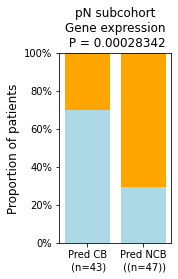

In [83]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import fisher_exact


# Example data
categories = [f'Pred CB\n (n={len(predRcb)+len(predNRncb)})', f'Pred NCB\n ((n={len(predNRcb)+len(predRncb)}))']
group1 = [len(predRcb), len(predNRcb)]
group2 = [len(predNRncb),len(predRncb)]

# Combine the groups into a single array
data = np.array([group1, group2])

# Normalize the data to make it 100% stacked
data_normalized = data / data.sum(axis=0)

# Plot
fig, ax = plt.subplots(figsize=(2, 3.5))

# Bottom stack starts at zero
bottom_stack = np.zeros(len(categories))

# Colors for each group
colors = ['lightblue', 'orange']
#colors = ["#005baa","#E7131A"]
# Labels for the legend
group_labels = ['Group 1', 'Group 2']

# Plot each group as a stack
for i in range(data.shape[0]):
    ax.bar(categories, data_normalized[i], bottom=bottom_stack, color=colors[i], label=group_labels[i])
    bottom_stack += data_normalized[i]

table = np.array([group1, group2])
res = fisher_exact(table, alternative='two-sided')
print(res)
# Customize the chart
ax.set_title('pN subcohort\nGene expression\n P = {:.8f}'.format(res.pvalue))
#ax.set_ylabel('Proportion of patients')
plt.ylabel('Proportion of patients', fontsize=12)
ax.set_ylim(0, 1)  # Ensure the y-axis goes from 0 to 1 (100%)
#ax.legend(title='Groups')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))  # Format y-axis as percentages

plt.savefig("gene_expression_ML-K10-barplot.svg",dpi=300,bbox_inches='tight')
# Display the chart
plt.show()


# network features input are avaiable:

In [12]:
edges_read = pd.read_csv("primaryNivo_common_edges_adjusted+var10000.txt",index_col=0)

edges_selected = edges_read.copy()
edges_input = edges_selected.loc[modelinput_expr.index,:]

In [13]:
from sklearn.feature_selection import SequentialFeatureSelector

lr准确率： 0.4444444444444444
lr的其他指标：
               precision    recall  f1-score   support

          CB       0.50      0.67      0.57        15
         NCB       0.29      0.17      0.21        12

    accuracy                           0.44        27
   macro avg       0.39      0.42      0.39        27
weighted avg       0.40      0.44      0.41        27



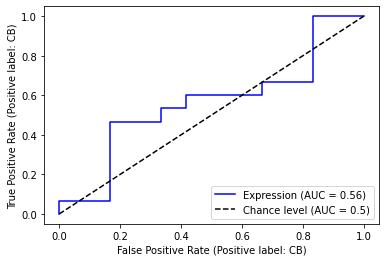

In [14]:
base_model = LogisticRegression(penalty='l2', C=1, max_iter=1000, random_state=42, class_weight='balanced')

X_train, X_test, y_train, y_test = train_test_split(edges_input, 
                                                     dfcl["Benefit"],
                                                   test_size=0.3,random_state=0)

# Combine feature selection and model into a pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),  
    ('feature_selection', SelectKBest( k= 100)),
    #('sequential_selection', SequentialFeatureSelector(base_model, n_features_to_select='auto', direction='forward', cv=5, n_jobs=-1)),
    ('logistic_regression', base_model)
])

# Fit the pipeline on training data
pipeline.fit(X_train, y_train)

lr_y_predict = pipeline.predict(X_test)

#fig, ax = plt.subplots() 
RocCurveDisplay.from_estimator(pipeline,X_test, y_test,pos_label="CB",plot_chance_level=True,name=f"Expression",c="blue")

print("lr准确率：", pipeline.score(X_test, y_test))
print("lr的其他指标：\n", classification_report(y_test, lr_y_predict, target_names=["CB", "NCB"],zero_division=0.0))


In [ ]:
# Spot Check Algorithms
# edges_input


from sklearn.model_selection import LeaveOneOut
for datetype,dataname in \
    zip([ edges_input.copy()],\
        ["edges"]):
            
    models = []
    models.append(('LR',LogisticRegression(penalty='l2',  C=1,max_iter=1000, random_state=42,class_weight ='balanced')))
    results = []
    names = []
    for name, model in models:
        # Define leave-one-out cross-validation
        loo = LeaveOneOut()
        for i in range(10,110,10):
            # Create a pipeline
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('feature_selection', SelectKBest(score_func=f_classif, k=i)), 
                ('logistic_regression', model)       # Logistic Regression model
        ])
        
            # Evaluate the pipeline with LOOCV
            scores = []
            y_resonse = []
            y_pred_list = []
            for train_index, test_index in loo.split(datetype):
                # Split data into train and test for this fold
                X_train, X_test = datetype.iloc[train_index], datetype.iloc[test_index]
                y_train, y_test = dfcl["Benefit"][train_index], dfcl["Benefit"][test_index]
                
                # Fit the pipeline on the training data
                pipeline.fit(X_train, y_train)
                
                # Predict on the test data
                y_pred = pipeline.predict(X_test)
                y_resonse.append(y_test)
                y_pred_list.append(y_pred)
                # Store the accuracy for this fold
                scores.append(accuracy_score(y_test, y_pred))  
                #print(scores)
            results.append(sum(scores)/len(scores))
            names.append(name)
            print(name, sum(scores)/len(scores))
        

In [15]:
# Spot Check Algorithms
# edges_input


from sklearn.model_selection import LeaveOneOut
for datetype,dataname in \
    zip([ edges_input.copy()],\
        ["edges"]):
            
    models = []
    models.append(('LR',LogisticRegression(penalty='l2',  C=1,max_iter=1000, random_state=42,class_weight ='balanced')))
    results = []
    names = []
    for name, model in models:
        # Define leave-one-out cross-validation
        loo = LeaveOneOut()

        # Create a pipeline
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('feature_selection', SelectKBest(score_func=f_classif, k=50)), 
            ('logistic_regression', model)       # Logistic Regression model
    ])
    
        # Evaluate the pipeline with LOOCV
        scores = []
        y_resonse = []
        y_pred_list = []
        for train_index, test_index in loo.split(datetype):
            # Split data into train and test for this fold
            X_train, X_test = datetype.iloc[train_index], datetype.iloc[test_index]
            y_train, y_test = dfcl["Benefit"][train_index], dfcl["Benefit"][test_index]
            
            # Fit the pipeline on the training data
            pipeline.fit(X_train, y_train)
            
            # Predict on the test data
            y_pred = pipeline.predict(X_test)
            y_resonse.append(y_test)
            y_pred_list.append(y_pred)
            # Store the accuracy for this fold
            scores.append(accuracy_score(y_test, y_pred))  
            #print(scores)
        results.append(sum(scores)/len(scores))
        names.append(name)
        print(name, sum(scores)/len(scores))
        

LR 0.7333333333333333


In [16]:
print(len(dfcl["Benefit"][np.array(scores) == 1]))

predC = dfcl["Benefit"][np.array(scores) == 1] 
predRcb = predC[predC =="CB"]
predRncb = predC[predC =="NCB"]
print(len(predRcb))
print(len(predRncb))

print(len(dfcl["Benefit"][np.array(scores) == 0]))
predIC = dfcl["Benefit"][np.array(scores) == 0] 
predNRcb = predIC[predIC =="CB"] # pred == NCB
predNRncb = predIC[predIC =="NCB"] # pred == CB
print(len(predNRcb))
print(len(predNRncb))

66
35
31
24
9
15


SignificanceResult(statistic=8.037037037037036, pvalue=7.89406744956653e-06)


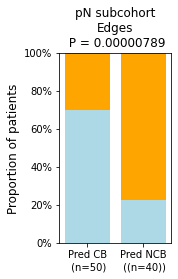

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import fisher_exact


# Example data
categories = [f'Pred CB\n (n={len(predRcb)+len(predNRncb)})', f'Pred NCB\n ((n={len(predNRcb)+len(predRncb)}))']
group1 = [len(predRcb), len(predNRcb)]
group2 = [len(predNRncb),len(predRncb)]

# Combine the groups into a single array
data = np.array([group1, group2])

# Normalize the data to make it 100% stacked
data_normalized = data / data.sum(axis=0)

# Plot
fig, ax = plt.subplots(figsize=(2, 3.5))

# Bottom stack starts at zero
bottom_stack = np.zeros(len(categories))

# Colors for each group
colors = ['lightblue', 'orange']

# Labels for the legend
group_labels = ['CB (n=44)', 'NCB (n=46)']

# Plot each group as a stack
for i in range(data.shape[0]):
    ax.bar(categories, data_normalized[i], bottom=bottom_stack, color=colors[i], label=group_labels[i])
    bottom_stack += data_normalized[i]

table = np.array([group1, group2])
res = fisher_exact(table, alternative='two-sided')
print(res)
# Customize the chart
ax.set_title('pN subcohort\nEdges\n P = {:.8f}'.format(res.pvalue))
plt.ylabel('Proportion of patients', fontsize=12)
ax.set_ylim(0, 1)  # Ensure the y-axis goes from 0 to 1 (100%)
#ax.legend(title='Groups')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))  # Format y-axis as percentages

plt.savefig("Edges_ML-K50-barplot.svg",dpi=300,bbox_inches='tight')
# Display the chart
plt.show()


# combination of gene expression and gene coexpression

In [18]:
modelinput_expr.join(edges_input,lsuffix='expr', rsuffix='edges')

,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2MP1,A3GALT2,A4GALT,...,HSD3B7_USP34,STK11_TAB2,ITCH_TUBGCP6,NIPBL_TGFB1,ETAA1_LRCH4,EIF3E_IL11RA,CCDC142_CSDE1,CCNL2_NEDD1,RPL37_STK11,ACTR2_ATG16L2
gene_name,,,,,,,,,,,,,,,,,,,,,
G138701_RCCBMS-00020-T_v1_RNA_OnPrem,30.187983,22.999432,33.643965,37.130851,22.705126,22.869853,21.076515,21.271282,21.807184,33.279532,...,-0.642597,-0.651356,-0.594918,-0.585138,-0.507149,-0.625087,-0.550042,-0.545841,-0.492360,-0.520370
G138701_RCCBMS-00097-T_v1_RNA_OnPrem,30.483638,25.581769,28.866645,37.945043,27.797609,24.142100,21.076515,21.271282,21.807184,33.019435,...,-0.535085,-0.651356,-0.529483,-0.585138,-0.507149,-0.519079,-0.550042,-0.479363,-0.492360,-0.520370
G138701_RCCBMS-00141-T_v1_RNA_OnPrem,30.092851,26.933385,26.684228,36.851946,22.705126,30.406352,21.076515,21.271282,21.807184,31.033210,...,-0.642597,-0.548588,-0.476628,-0.585138,-0.635350,-0.519079,-0.550042,-0.537486,-0.594656,-0.520370
G138701_RCCBMS-00099-T_v1_RNA_OnPrem,30.975010,26.683128,32.521494,38.453517,26.337846,28.229357,21.076515,21.271282,26.484608,33.009203,...,-0.642597,-0.548588,-0.594918,-0.585138,-0.561262,-0.519079,-0.550042,-0.543265,-0.594656,-0.623699
G138701_RCCBMS-00053-T_v1_RNA_OnPrem,30.731451,22.999432,25.282264,37.915010,22.705126,28.859039,21.076515,21.271282,21.807184,31.851192,...,-0.535085,-0.651356,-0.476628,-0.585138,-0.507149,-0.625087,-0.652548,-0.607391,-0.594656,-0.623699
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
EA639040,31.805473,26.396573,32.109799,37.371641,27.068437,26.405412,20.976688,20.889661,24.824862,33.061771,...,-0.535085,-0.651356,-0.594918,-0.585138,-0.635350,-0.625087,-0.652548,-0.607391,-0.594656,-0.623699
P66507-04D-Run1_S3_L001,29.718678,21.286965,33.059162,35.566022,21.357557,27.686244,20.980667,25.034267,21.018133,33.704298,...,-0.535085,-0.651356,-0.476628,-0.476673,-0.561760,-0.519079,-0.652548,-0.607391,-0.594656,-0.520370
P66507-07G-Run1_S17_L002,31.147910,21.286965,31.617351,37.423994,21.357557,27.720569,20.980667,20.992693,28.011280,35.638479,...,-0.642597,-0.651356,-0.594918,-0.585138,-0.635350,-0.625087,-0.550042,-0.607391,-0.594656,-0.623699


In [20]:
# Spot Check Algorithms
# edges_input

df_edge_expression = {}

from sklearn.model_selection import LeaveOneOut
for datetype,dataname in \
    zip([ modelinput_expr.join(edges_input,lsuffix='expr', rsuffix='edges').copy()],\
        ["expression+edges"]):
            
    models = []
    models.append(('LR',LogisticRegression(penalty='l2',  C=1,max_iter=1000, random_state=42,class_weight ='balanced')))
    results = []
    names = []
    for name, model in models:
        # Define leave-one-out cross-validation
        loo = LeaveOneOut()
        for i in range(5,6):
            
            # Create a pipeline
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('feature_selection', SelectKBest(score_func=f_classif, k=i*10)), 
                ('logistic_regression', model)       # Logistic Regression model
        ])
        
            # Evaluate the pipeline with LOOCV
            scores = []
            y_resonse = []
            y_pred_list = []
            for train_index, test_index in loo.split(datetype):
                # Split data into train and test for this fold
                X_train, X_test = datetype.iloc[train_index], datetype.iloc[test_index]
                y_train, y_test = dfcl["Benefit"][train_index], dfcl["Benefit"][test_index]
                
                # Fit the pipeline on the training data
                pipeline.fit(X_train, y_train)

                # Access the SelectKBest step
                select_kbest = pipeline.named_steps['feature_selection']
                # Get the selected features
                selected_mask = select_kbest.get_support()  # Boolean mask
                selected_features = X_train.columns[selected_mask]  # Feature names
                #print("Selected Features:", selected_features)
                
                # View the scores of all features
                feature_scores = select_kbest.scores_  # ANOVA F-values for each feature
                df_edge_expression[test_index[0]] = pd.DataFrame({'Feature': X_train.columns, 'Score': feature_scores})

                
                # Predict on the test data
                y_pred = pipeline.predict(X_test)
                y_resonse.append(y_test)
                y_pred_list.append(y_pred)
                # Store the accuracy for this fold
                scores.append(accuracy_score(y_test, y_pred))  
            #print(scores)
            results.append(sum(scores)/len(scores))
            names.append(name)
            print(name, sum(scores)/len(scores))
        

LR 0.7555555555555555


combined = pd.concat([df_edge_expression[i].sort_values("Score",ascending=False)[:50].assign(loocv=i) for i in range(0,90)], axis=0)

combined.to_csv("network_features_gene_expression_top50_loocv.txt",sep="\t",index=None)

In [21]:
print(len(dfcl["Benefit"][np.array(scores) == 1]))

predC = dfcl["Benefit"][np.array(scores) == 1] 
predRcb = predC[predC =="CB"]
predRncb = predC[predC =="NCB"]
print(len(predRcb))
print(len(predRncb))

print(len(dfcl["Benefit"][np.array(scores) == 0]))
predIC = dfcl["Benefit"][np.array(scores) == 0] 
predNRcb = predIC[predIC =="CB"] # pred == NCB
predNRncb = predIC[predIC =="NCB"] # pred == CB
print(len(predNRcb))
print(len(predNRncb))

68
33
35
22
11
11


SignificanceResult(statistic=9.545454545454545, pvalue=2.166286445847165e-06)


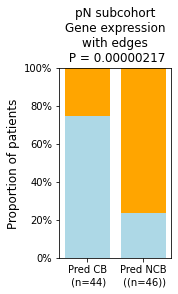

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import fisher_exact


# Example data
categories = [f'Pred CB\n (n={len(predRcb)+len(predNRncb)})', f'Pred NCB\n ((n={len(predNRcb)+len(predRncb)}))']
group1 = [len(predRcb), len(predNRcb)]
group2 = [len(predNRncb),len(predRncb)]

# Combine the groups into a single array
data = np.array([group1, group2])

# Normalize the data to make it 100% stacked
data_normalized = data / data.sum(axis=0)

# Plot
fig, ax = plt.subplots(figsize=(2, 3.5))

# Bottom stack starts at zero
bottom_stack = np.zeros(len(categories))

# Colors for each group
colors = ['lightblue', 'orange']

# Labels for the legend
group_labels = ['Group 1', 'Group 2']

# Plot each group as a stack
for i in range(data.shape[0]):
    ax.bar(categories, data_normalized[i], bottom=bottom_stack, color=colors[i], label=group_labels[i])
    bottom_stack += data_normalized[i]

table = np.array([group1, group2])
res = fisher_exact(table, alternative='two-sided')
print(res)
# Customize the chart
ax.set_title('pN subcohort\nGene expression\nwith edges\n P = {:.8f}'.format(res.pvalue))
#ax.set_ylabel('Proportion of patients')
ax.set_ylim(0, 1)  # Ensure the y-axis goes from 0 to 1 (100%)
#ax.legend(title='Groups')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))  # Format y-axis as percentages
plt.ylabel('Proportion of patients', fontsize=12)
plt.savefig("Edges_expr_combination_ML-K50-barplot.svg",dpi=300,bbox_inches='tight')
# Display the chart
plt.show()


## gene pos connectivity

In [23]:
connectivity_pos_selected = pd.read_csv("primaryNivo.positive.connectivity_adjusted.txt",index_col=1)
connectivity_neg_selected = pd.read_csv("primaryNivo.negative.connectivity_adjusted.txt",index_col=1)

connec_pos_input = connectivity_pos_selected.loc[modelinput_expr.index,:].iloc[:,1:]
connec_pos_input_improved = modelinput_expr.join(connec_pos_input,lsuffix='expr', rsuffix='conp')
connec_pos_input_improved.shape

connec_neg_input = connectivity_neg_selected.loc[modelinput_expr.index,:].iloc[:,1:]
connec_neg_input_improved = modelinput_expr.join(connec_neg_input,lsuffix='expr', rsuffix='conn')
connec_neg_input_improved.shape

(90, 41090)

In [24]:
connec_pos_input.index == dfcl["Benefit"].index

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True])

In [86]:
# Spot Check Algorithms
# edges_input

df_connectivity_pos = {}

from sklearn.model_selection import LeaveOneOut
for datetype,dataname in \
    zip([ connec_pos_input.copy()],\
        ["connec_pos"]):
            
    models = []
    models.append(('LR',LogisticRegression(penalty='l2',  C=1,max_iter=1000, random_state=42,class_weight ='balanced')))
    results = []
    names = []
    for name, model in models:
        # Define leave-one-out cross-validation
        loo = LeaveOneOut()
        for i in range(1,11):
            
            # Create a pipeline
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('feature_selection', SelectKBest(score_func=f_classif, k=i*10)), 
                ('logistic_regression', model)       # Logistic Regression model
        ])
        
            # Evaluate the pipeline with LOOCV
            scores = []
            y_resonse = []
            y_pred_list = []
            for train_index, test_index in loo.split(datetype):
                # Split data into train and test for this fold
                X_train, X_test = datetype.iloc[train_index], datetype.iloc[test_index]
                y_train, y_test = dfcl["Benefit"][train_index], dfcl["Benefit"][test_index]
                
                # Fit the pipeline on the training data
                pipeline.fit(X_train, y_train)

                # Access the SelectKBest step
                select_kbest = pipeline.named_steps['feature_selection']
                # Get the selected features
                selected_mask = select_kbest.get_support()  # Boolean mask
                selected_features = X_train.columns[selected_mask]  # Feature names
                #print("Selected Features:", selected_features)
                
                # View the scores of all features
                feature_scores = select_kbest.scores_  # ANOVA F-values for each feature
                df_connectivity_pos[test_index[0]] = pd.DataFrame({'Feature': X_train.columns, 'Score': feature_scores})

                
                # Predict on the test data
                y_pred = pipeline.predict(X_test)
                y_resonse.append(y_test)
                y_pred_list.append(y_pred)
                # Store the accuracy for this fold
                scores.append(accuracy_score(y_test, y_pred))  
            #print(scores)
            results.append(sum(scores)/len(scores))
            names.append(name)
            print(name, sum(scores)/len(scores))
        

LR 0.28888888888888886
LR 0.4
LR 0.45555555555555555
LR 0.5444444444444444
LR 0.5888888888888889
LR 0.5666666666666667
LR 0.5888888888888889
LR 0.5777777777777777
LR 0.6222222222222222
LR 0.5888888888888889


In [25]:
# Spot Check Algorithms
# edges_input

df_connectivity_pos = {}

from sklearn.model_selection import LeaveOneOut
for datetype,dataname in \
    zip([ connec_pos_input.copy()],\
        ["connec_pos"]):
            
    models = []
    models.append(('LR',LogisticRegression(penalty='l2',  C=1,max_iter=1000, random_state=42,class_weight ='balanced')))
    results = []
    names = []
    for name, model in models:
        # Define leave-one-out cross-validation
        loo = LeaveOneOut()
        for i in range(9,10):
            
            # Create a pipeline
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('feature_selection', SelectKBest(score_func=f_classif, k=i*10)), 
                ('logistic_regression', model)       # Logistic Regression model
        ])
        
            # Evaluate the pipeline with LOOCV
            scores = []
            y_resonse = []
            y_pred_list = []
            for train_index, test_index in loo.split(datetype):
                # Split data into train and test for this fold
                X_train, X_test = datetype.iloc[train_index], datetype.iloc[test_index]
                y_train, y_test = dfcl["Benefit"][train_index], dfcl["Benefit"][test_index]
                
                # Fit the pipeline on the training data
                pipeline.fit(X_train, y_train)

                # Access the SelectKBest step
                select_kbest = pipeline.named_steps['feature_selection']
                # Get the selected features
                selected_mask = select_kbest.get_support()  # Boolean mask
                selected_features = X_train.columns[selected_mask]  # Feature names
                #print("Selected Features:", selected_features)
                
                # View the scores of all features
                feature_scores = select_kbest.scores_  # ANOVA F-values for each feature
                df_connectivity_pos[test_index[0]] = pd.DataFrame({'Feature': X_train.columns, 'Score': feature_scores})

                
                # Predict on the test data
                y_pred = pipeline.predict(X_test)
                y_resonse.append(y_test)
                y_pred_list.append(y_pred)
                # Store the accuracy for this fold
                scores.append(accuracy_score(y_test, y_pred))  
            #print(scores)
            results.append(sum(scores)/len(scores))
            names.append(name)
            print(name, sum(scores)/len(scores))
        

LR 0.6222222222222222


In [26]:
print(len(dfcl["Benefit"][np.array(scores) == 1]))

predC = dfcl["Benefit"][np.array(scores) == 1] 
predRcb = predC[predC =="CB"]
predRncb = predC[predC =="NCB"]
print(len(predRcb))
print(len(predRncb))

print(len(dfcl["Benefit"][np.array(scores) == 0]))
predIC = dfcl["Benefit"][np.array(scores) == 0] 
predNRcb = predIC[predIC =="CB"] # pred == NCB
predNRncb = predIC[predIC =="NCB"] # pred == CB
print(len(predNRcb))
print(len(predNRncb))

56
23
33
34
21
13


SignificanceResult(statistic=2.78021978021978, pvalue=0.03088236719296033)


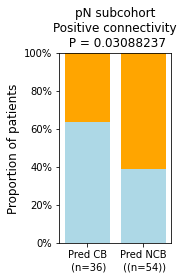

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import fisher_exact


# Example data
categories = [f'Pred CB\n (n={len(predRcb)+len(predNRncb)})', f'Pred NCB\n ((n={len(predNRcb)+len(predRncb)}))']
group1 = [len(predRcb), len(predNRcb)]
group2 = [len(predNRncb),len(predRncb)]

# Combine the groups into a single array
data = np.array([group1, group2])

# Normalize the data to make it 100% stacked
data_normalized = data / data.sum(axis=0)

# Plot
fig, ax = plt.subplots(figsize=(2, 3.5))

# Bottom stack starts at zero
bottom_stack = np.zeros(len(categories))

# Colors for each group
colors = ['lightblue', 'orange']

# Labels for the legend
group_labels = ['Group 1', 'Group 2']

# Plot each group as a stack
for i in range(data.shape[0]):
    ax.bar(categories, data_normalized[i], bottom=bottom_stack, color=colors[i], label=group_labels[i])
    bottom_stack += data_normalized[i]

table = np.array([group1, group2])
res = fisher_exact(table, alternative='two-sided')
print(res)
# Customize the chart
ax.set_title('pN subcohort\nPositive connectivity\n P = {:.8f}'.format(res.pvalue))
#ax.set_ylabel('Proportion of patients')
ax.set_ylim(0, 1)  # Ensure the y-axis goes from 0 to 1 (100%)
#ax.legend(title='Groups')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))  # Format y-axis as percentages
plt.ylabel('Proportion of patients', fontsize=12)
plt.savefig("connec_pos_ML-K90-barplot.svg",dpi=300,bbox_inches='tight')
# Display the chart
plt.show()


In [90]:
connec_neg_input

,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1-AS1,A2MP1,A3GALT2,A4GALT,A4GNT,...,BCL2L2-PABPN1,LINC00316,MLIP-IT1,ST7-AS1,IGLV1-50,SPATA19,SETSIP,ZNF774,CYTL1,OR10G3
gene_name,,,,,,,,,,,,,,,,,,,,,
G138701_RCCBMS-00020-T_v1_RNA_OnPrem,20.098340,4.004365,48.230769,23.402286,2.808523,4.985339,0.398209,1.973750,247.125305,21.771941,...,0.373714,0.425165,0.433938,2.456490,0.865243,0.420388,11.864616,0.375820,3.233170,0.411150
G138701_RCCBMS-00097-T_v1_RNA_OnPrem,32.191956,0.400724,28.794606,39.138475,11.451415,0.773871,0.398209,3.095702,259.374971,39.558146,...,0.373714,0.425165,0.433938,0.376722,0.384982,0.420388,10.505523,0.375820,0.381227,0.411150
G138701_RCCBMS-00141-T_v1_RNA_OnPrem,21.580520,0.420987,109.294522,22.865618,3.626327,0.773871,0.398209,3.289209,358.243633,74.941145,...,0.373714,0.425165,0.433938,0.790305,5.986657,0.420388,0.765300,0.375820,5.658303,0.411150
G138701_RCCBMS-00099-T_v1_RNA_OnPrem,22.720399,0.388846,37.036121,73.594223,4.761523,0.773871,0.528614,4.504262,228.642376,21.454868,...,0.373714,0.425165,0.433938,4.396744,1.198339,0.420388,0.422620,0.376824,0.381227,0.411150
G138701_RCCBMS-00053-T_v1_RNA_OnPrem,15.129678,0.387475,117.730794,23.545359,1.735100,17.776733,0.398209,1.225491,227.876408,19.201667,...,1.605246,0.425165,0.433938,0.376722,0.384982,0.420388,0.376115,0.375820,0.381227,0.411150
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
EA639040,28.495517,0.782693,30.064048,20.565540,3.322309,14.042735,1.057252,7.624272,246.288375,20.374532,...,0.373714,2.315913,0.433938,0.376722,0.384982,0.420388,0.376115,0.375820,0.381227,0.411150
P66507-04D-Run1_S3_L001,12.178283,7.794987,31.057713,169.241725,8.556393,6.149714,1186.749928,1.419029,274.190768,22.236485,...,51.296774,0.425165,0.433938,2.783654,4.525923,0.420388,8.326669,1.220935,16.041997,0.411150
P66507-07G-Run1_S17_L002,3.437975,8.693933,8.158370,5.797169,6.854758,17.661779,0.475258,43.458883,527.308939,3.570280,...,39.945381,0.425165,0.433938,2.980556,4.071402,0.420388,1.809311,98.136528,12.006931,0.411150


In [89]:
# Spot Check Algorithms
# edges_input

df_connectivity_neg = {}

from sklearn.model_selection import LeaveOneOut
for datetype,dataname in \
    zip([ connec_neg_input.copy()],\
        ["connec_neg"]):
            
    models = []
    models.append(('LR',LogisticRegression(penalty='l2',  C=1,max_iter=1000, random_state=42,class_weight ='balanced')))
    results = []
    names = []
    for name, model in models:
        # Define leave-one-out cross-validation
        loo = LeaveOneOut()
        for i in range(1,11):
            
            # Create a pipeline
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('feature_selection', SelectKBest(score_func=f_classif, k=i*10)), 
                ('logistic_regression', model)       # Logistic Regression model
        ])
        
            # Evaluate the pipeline with LOOCV
            scores = []
            y_resonse = []
            y_pred_list = []
            for train_index, test_index in loo.split(datetype):
                # Split data into train and test for this fold
                X_train, X_test = datetype.iloc[train_index], datetype.iloc[test_index]
                y_train, y_test = dfcl["Benefit"][train_index], dfcl["Benefit"][test_index]
                
                # Fit the pipeline on the training data
                pipeline.fit(X_train, y_train)

                # Access the SelectKBest step
                select_kbest = pipeline.named_steps['feature_selection']
                # Get the selected features
                selected_mask = select_kbest.get_support()  # Boolean mask
                selected_features = X_train.columns[selected_mask]  # Feature names
                #print("Selected Features:", selected_features)
                
                # View the scores of all features
                feature_scores = select_kbest.scores_  # ANOVA F-values for each feature
                df_connectivity_neg[test_index[0]] = pd.DataFrame({'Feature': X_train.columns, 'Score': feature_scores})

                
                # Predict on the test data
                y_pred = pipeline.predict(X_test)
                y_resonse.append(y_test)
                y_pred_list.append(y_pred)
                # Store the accuracy for this fold
                scores.append(accuracy_score(y_test, y_pred))  
            #print(scores)
            results.append(sum(scores)/len(scores))
            names.append(name)
            print(name, sum(scores)/len(scores))
        

LR 0.5
LR 0.5
LR 0.5555555555555556
LR 0.4666666666666667
LR 0.35555555555555557
LR 0.37777777777777777
LR 0.3888888888888889
LR 0.43333333333333335
LR 0.43333333333333335
LR 0.4444444444444444


In [28]:
# Spot Check Algorithms
# edges_input

df_connectivity_neg = {}

from sklearn.model_selection import LeaveOneOut
for datetype,dataname in \
    zip([ connec_neg_input.copy()],\
        ["connec_neg"]):
            
    models = []
    models.append(('LR',LogisticRegression(penalty='l2',  C=1,max_iter=1000, random_state=42,class_weight ='balanced')))
    results = []
    names = []
    for name, model in models:
        # Define leave-one-out cross-validation
        loo = LeaveOneOut()
        for i in range(3,4):
            
            # Create a pipeline
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('feature_selection', SelectKBest(score_func=f_classif, k=i*10)), 
                ('logistic_regression', model)       # Logistic Regression model
        ])
        
            # Evaluate the pipeline with LOOCV
            scores = []
            y_resonse = []
            y_pred_list = []
            for train_index, test_index in loo.split(datetype):
                # Split data into train and test for this fold
                X_train, X_test = datetype.iloc[train_index], datetype.iloc[test_index]
                y_train, y_test = dfcl["Benefit"][train_index], dfcl["Benefit"][test_index]
                
                # Fit the pipeline on the training data
                pipeline.fit(X_train, y_train)

                # Access the SelectKBest step
                select_kbest = pipeline.named_steps['feature_selection']
                # Get the selected features
                selected_mask = select_kbest.get_support()  # Boolean mask
                selected_features = X_train.columns[selected_mask]  # Feature names
                #print("Selected Features:", selected_features)
                
                # View the scores of all features
                feature_scores = select_kbest.scores_  # ANOVA F-values for each feature
                df_connectivity_neg[test_index[0]] = pd.DataFrame({'Feature': X_train.columns, 'Score': feature_scores})

                
                # Predict on the test data
                y_pred = pipeline.predict(X_test)
                y_resonse.append(y_test)
                y_pred_list.append(y_pred)
                # Store the accuracy for this fold
                scores.append(accuracy_score(y_test, y_pred))  
            #print(scores)
            results.append(sum(scores)/len(scores))
            names.append(name)
            print(name, sum(scores)/len(scores))
        

LR 0.5555555555555556


In [29]:
print(len(dfcl["Benefit"][np.array(scores) == 1]))

predC = dfcl["Benefit"][np.array(scores) == 1] 
predRcb = predC[predC =="CB"]
predRncb = predC[predC =="NCB"]
print(len(predRcb))
print(len(predRncb))

print(len(dfcl["Benefit"][np.array(scores) == 0]))
predIC = dfcl["Benefit"][np.array(scores) == 0] 
predNRcb = predIC[predIC =="CB"] # pred == NCB
predNRncb = predIC[predIC =="NCB"] # pred == CB
print(len(predNRcb))
print(len(predNRncb))

50
26
24
40
18
22


SignificanceResult(statistic=1.5757575757575757, pvalue=0.29996387557963516)


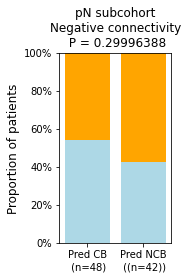

In [30]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import fisher_exact


# Example data
categories = [f'Pred CB\n (n={len(predRcb)+len(predNRncb)})', f'Pred NCB\n ((n={len(predNRcb)+len(predRncb)}))']
group1 = [len(predRcb), len(predNRcb)]
group2 = [len(predNRncb),len(predRncb)]

# Combine the groups into a single array
data = np.array([group1, group2])

# Normalize the data to make it 100% stacked
data_normalized = data / data.sum(axis=0)

# Plot
fig, ax = plt.subplots(figsize=(2, 3.5))

# Bottom stack starts at zero
bottom_stack = np.zeros(len(categories))

# Colors for each group
colors = ['lightblue', 'orange']

# Labels for the legend
group_labels = ['Group 1', 'Group 2']

# Plot each group as a stack
for i in range(data.shape[0]):
    ax.bar(categories, data_normalized[i], bottom=bottom_stack, color=colors[i], label=group_labels[i])
    bottom_stack += data_normalized[i]

table = np.array([group1, group2])
res = fisher_exact(table, alternative='two-sided')
print(res)
# Customize the chart
ax.set_title('pN subcohort\nNegative connectivity\n P = {:.8f}'.format(res.pvalue))
#ax.set_ylabel('Proportion of patients')
ax.set_ylim(0, 1)  # Ensure the y-axis goes from 0 to 1 (100%)
#ax.legend(title='Groups')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))  # Format y-axis as percentages
plt.ylabel('Proportion of patients', fontsize=12)
plt.savefig("connec_neg_ML-K30-barplot.svg",dpi=300,bbox_inches='tight')
# Display the chart
plt.show()


## gene pos connectivity + expression

In [91]:
# Spot Check Algorithms
# edges_input

df_connectivity_pos_improved = {}

from sklearn.model_selection import LeaveOneOut
for datetype,dataname in \
    zip([ connec_pos_input_improved .copy()],\
        ["expression+gene pos connectivity"]):
            
    models = []
    models.append(('LR',LogisticRegression(penalty='l2',  C=1,max_iter=1000, random_state=42,class_weight ='balanced')))
    results = []
    names = []
    for name, model in models:
        # Define leave-one-out cross-validation
        loo = LeaveOneOut()
        for i in range(1,11):
            
            # Create a pipeline
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('feature_selection', SelectKBest(score_func=f_classif, k=i*10)), 
                ('logistic_regression', model)       # Logistic Regression model
        ])
        
            # Evaluate the pipeline with LOOCV
            scores = []
            y_resonse = []
            y_pred_list = []
            for train_index, test_index in loo.split(datetype):
                # Split data into train and test for this fold
                X_train, X_test = datetype.iloc[train_index], datetype.iloc[test_index]
                y_train, y_test = dfcl["Benefit"][train_index], dfcl["Benefit"][test_index]
                
                # Fit the pipeline on the training data
                pipeline.fit(X_train, y_train)

                # Access the SelectKBest step
                select_kbest = pipeline.named_steps['feature_selection']
                # Get the selected features
                selected_mask = select_kbest.get_support()  # Boolean mask
                selected_features = X_train.columns[selected_mask]  # Feature names
                #print("Selected Features:", selected_features)
                
                # View the scores of all features
                feature_scores = select_kbest.scores_  # ANOVA F-values for each feature
                df_connectivity_pos_improved[test_index[0]] = pd.DataFrame({'Feature': X_train.columns, 'Score': feature_scores})

                
                # Predict on the test data
                y_pred = pipeline.predict(X_test)
                y_resonse.append(y_test)
                y_pred_list.append(y_pred)
                # Store the accuracy for this fold
                scores.append(accuracy_score(y_test, y_pred))  
            #print(scores)
            results.append(sum(scores)/len(scores))
            names.append(name)
            print(name, sum(scores)/len(scores))
        

LR 0.6444444444444445
LR 0.6
LR 0.4888888888888889
LR 0.5111111111111111
LR 0.5777777777777777
LR 0.5777777777777777
LR 0.6333333333333333
LR 0.6111111111111112
LR 0.5666666666666667
LR 0.5555555555555556


In [31]:
# Spot Check Algorithms
# edges_input

df_connectivity_pos_improved = {}

from sklearn.model_selection import LeaveOneOut
for datetype,dataname in \
    zip([ connec_pos_input_improved .copy()],\
        ["expression+gene pos connectivity"]):
            
    models = []
    models.append(('LR',LogisticRegression(penalty='l2',  C=1,max_iter=1000, random_state=42,class_weight ='balanced')))
    results = []
    names = []
    for name, model in models:
        # Define leave-one-out cross-validation
        loo = LeaveOneOut()
        for i in range(1,2):
            
            # Create a pipeline
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('feature_selection', SelectKBest(score_func=f_classif, k=i*10)), 
                ('logistic_regression', model)       # Logistic Regression model
        ])
        
            # Evaluate the pipeline with LOOCV
            scores = []
            y_resonse = []
            y_pred_list = []
            for train_index, test_index in loo.split(datetype):
                # Split data into train and test for this fold
                X_train, X_test = datetype.iloc[train_index], datetype.iloc[test_index]
                y_train, y_test = dfcl["Benefit"][train_index], dfcl["Benefit"][test_index]
                
                # Fit the pipeline on the training data
                pipeline.fit(X_train, y_train)

                # Access the SelectKBest step
                select_kbest = pipeline.named_steps['feature_selection']
                # Get the selected features
                selected_mask = select_kbest.get_support()  # Boolean mask
                selected_features = X_train.columns[selected_mask]  # Feature names
                #print("Selected Features:", selected_features)
                
                # View the scores of all features
                feature_scores = select_kbest.scores_  # ANOVA F-values for each feature
                df_connectivity_pos_improved[test_index[0]] = pd.DataFrame({'Feature': X_train.columns, 'Score': feature_scores})

                
                # Predict on the test data
                y_pred = pipeline.predict(X_test)
                y_resonse.append(y_test)
                y_pred_list.append(y_pred)
                # Store the accuracy for this fold
                scores.append(accuracy_score(y_test, y_pred))  
            #print(scores)
            results.append(sum(scores)/len(scores))
            names.append(name)
            print(name, sum(scores)/len(scores))
        

LR 0.6444444444444445


In [32]:
print(len(dfcl["Benefit"][np.array(scores) == 1]))

predC = dfcl["Benefit"][np.array(scores) == 1] 
predRcb = predC[predC =="CB"]
predRncb = predC[predC =="NCB"]
print(len(predRcb))
print(len(predRncb))

print(len(dfcl["Benefit"][np.array(scores) == 0]))
predIC = dfcl["Benefit"][np.array(scores) == 0] 
predNRcb = predIC[predIC =="CB"] # pred == NCB
predNRncb = predIC[predIC =="NCB"] # pred == CB
print(len(predNRcb))
print(len(predNRncb))

58
28
30
32
16
16


SignificanceResult(statistic=3.28125, pvalue=0.010961709272500666)


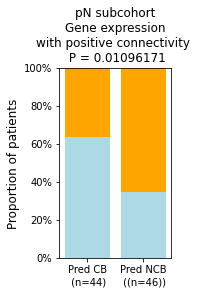

In [33]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import fisher_exact


# Example data
categories = [f'Pred CB\n (n={len(predRcb)+len(predNRncb)})', f'Pred NCB\n ((n={len(predNRcb)+len(predRncb)}))']
group1 = [len(predRcb), len(predNRcb)]
group2 = [len(predNRncb),len(predRncb)]

# Combine the groups into a single array
data = np.array([group1, group2])

# Normalize the data to make it 100% stacked
data_normalized = data / data.sum(axis=0)

# Plot
fig, ax = plt.subplots(figsize=(2, 3.5))

# Bottom stack starts at zero
bottom_stack = np.zeros(len(categories))

# Colors for each group
colors = ['lightblue', 'orange']

# Labels for the legend
group_labels = ['Group 1', 'Group 2']

# Plot each group as a stack
for i in range(data.shape[0]):
    ax.bar(categories, data_normalized[i], bottom=bottom_stack, color=colors[i], label=group_labels[i])
    bottom_stack += data_normalized[i]

table = np.array([group1, group2])
res = fisher_exact(table, alternative='two-sided')
print(res)
# Customize the chart
ax.set_title('pN subcohort\nGene expression\nwith positive connectivity \n P = {:.8f}'.format(res.pvalue))
#ax.set_ylabel('Proportion of patients')
ax.set_ylim(0, 1)  # Ensure the y-axis goes from 0 to 1 (100%)
#ax.legend(title='Groups')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))  # Format y-axis as percentages
plt.ylabel('Proportion of patients', fontsize=12)
plt.savefig("connec_pos_expr_ML-K10-barplot.svg",dpi=300,bbox_inches='tight')
# Display the chart
plt.show()


## gene neg connectivity + expression

In [92]:
# Spot Check Algorithms
# edges_input

df_connectivity_neg_improved = {}

from sklearn.model_selection import LeaveOneOut
for datetype,dataname in \
    zip([ connec_neg_input_improved .copy()],\
        ["expression+gene pos connectivity"]):
            
    models = []
    models.append(('LR',LogisticRegression(penalty='l2',  C=1,max_iter=1000, random_state=42,class_weight ='balanced')))
    results = []
    names = []
    for name, model in models:
        # Define leave-one-out cross-validation
        loo = LeaveOneOut()
        for i in range(1,11):
            
            # Create a pipeline
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('feature_selection', SelectKBest(score_func=f_classif, k=i*10)), 
                ('logistic_regression', model)       # Logistic Regression model
        ])
        
            # Evaluate the pipeline with LOOCV
            scores = []
            y_resonse = []
            y_pred_list = []
            for train_index, test_index in loo.split(datetype):
                # Split data into train and test for this fold
                X_train, X_test = datetype.iloc[train_index], datetype.iloc[test_index]
                y_train, y_test = dfcl["Benefit"][train_index], dfcl["Benefit"][test_index]
                
                # Fit the pipeline on the training data
                pipeline.fit(X_train, y_train)

                # Access the SelectKBest step
                select_kbest = pipeline.named_steps['feature_selection']
                # Get the selected features
                selected_mask = select_kbest.get_support()  # Boolean mask
                selected_features = X_train.columns[selected_mask]  # Feature names
                #print("Selected Features:", selected_features)
                
                # View the scores of all features
                feature_scores = select_kbest.scores_  # ANOVA F-values for each feature
                df_connectivity_neg_improved[test_index[0]] = pd.DataFrame({'Feature': X_train.columns, 'Score': feature_scores})

                
                # Predict on the test data
                y_pred = pipeline.predict(X_test)
                y_resonse.append(y_test)
                y_pred_list.append(y_pred)
                # Store the accuracy for this fold
                scores.append(accuracy_score(y_test, y_pred))  
            #print(scores)
            results.append(sum(scores)/len(scores))
            names.append(name)
            print(name, sum(scores)/len(scores))
        

LR 0.7111111111111111
LR 0.6222222222222222
LR 0.5666666666666667
LR 0.5444444444444444
LR 0.5444444444444444
LR 0.5222222222222223
LR 0.5444444444444444
LR 0.5333333333333333
LR 0.5
LR 0.4777777777777778


In [34]:
# Spot Check Algorithms
# edges_input

df_connectivity_neg_improved = {}

from sklearn.model_selection import LeaveOneOut
for datetype,dataname in \
    zip([ connec_neg_input_improved .copy()],\
        ["expression+gene pos connectivity"]):
            
    models = []
    models.append(('LR',LogisticRegression(penalty='l2',  C=1,max_iter=1000, random_state=42,class_weight ='balanced')))
    results = []
    names = []
    for name, model in models:
        # Define leave-one-out cross-validation
        loo = LeaveOneOut()
        for i in range(1,2):
            
            # Create a pipeline
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('feature_selection', SelectKBest(score_func=f_classif, k=i*10)), 
                ('logistic_regression', model)       # Logistic Regression model
        ])
        
            # Evaluate the pipeline with LOOCV
            scores = []
            y_resonse = []
            y_pred_list = []
            for train_index, test_index in loo.split(datetype):
                # Split data into train and test for this fold
                X_train, X_test = datetype.iloc[train_index], datetype.iloc[test_index]
                y_train, y_test = dfcl["Benefit"][train_index], dfcl["Benefit"][test_index]
                
                # Fit the pipeline on the training data
                pipeline.fit(X_train, y_train)

                # Access the SelectKBest step
                select_kbest = pipeline.named_steps['feature_selection']
                # Get the selected features
                selected_mask = select_kbest.get_support()  # Boolean mask
                selected_features = X_train.columns[selected_mask]  # Feature names
                #print("Selected Features:", selected_features)
                
                # View the scores of all features
                feature_scores = select_kbest.scores_  # ANOVA F-values for each feature
                df_connectivity_neg_improved[test_index[0]] = pd.DataFrame({'Feature': X_train.columns, 'Score': feature_scores})

                
                # Predict on the test data
                y_pred = pipeline.predict(X_test)
                y_resonse.append(y_test)
                y_pred_list.append(y_pred)
                # Store the accuracy for this fold
                scores.append(accuracy_score(y_test, y_pred))  
            #print(scores)
            results.append(sum(scores)/len(scores))
            names.append(name)
            print(name, sum(scores)/len(scores))
        

LR 0.7111111111111111


In [35]:
print(len(dfcl["Benefit"][np.array(scores) == 1]))

predC = dfcl["Benefit"][np.array(scores) == 1] 
predRcb = predC[predC =="CB"]
predRncb = predC[predC =="NCB"]
print(len(predRcb))
print(len(predRncb))

print(len(dfcl["Benefit"][np.array(scores) == 0]))
predIC = dfcl["Benefit"][np.array(scores) == 0] 
predNRcb = predIC[predIC =="CB"] # pred == NCB
predNRncb = predIC[predIC =="NCB"] # pred == CB
print(len(predNRcb))
print(len(predNRncb))

64
30
34
26
14
12


SignificanceResult(statistic=6.071428571428571, pvalue=0.0001157540527563468)


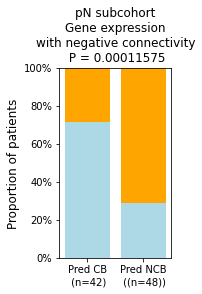

In [36]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import fisher_exact


# Example data
categories = [f'Pred CB\n (n={len(predRcb)+len(predNRncb)})', f'Pred NCB\n ((n={len(predNRcb)+len(predRncb)}))']
group1 = [len(predRcb), len(predNRcb)]
group2 = [len(predNRncb),len(predRncb)]

# Combine the groups into a single array
data = np.array([group1, group2])

# Normalize the data to make it 100% stacked
data_normalized = data / data.sum(axis=0)

# Plot
fig, ax = plt.subplots(figsize=(2, 3.5))

# Bottom stack starts at zero
bottom_stack = np.zeros(len(categories))

# Colors for each group
colors = ['lightblue', 'orange']

# Labels for the legend
group_labels = ['Group 1', 'Group 2']

# Plot each group as a stack
for i in range(data.shape[0]):
    ax.bar(categories, data_normalized[i], bottom=bottom_stack, color=colors[i], label=group_labels[i])
    bottom_stack += data_normalized[i]

table = np.array([group1, group2])
res = fisher_exact(table, alternative='two-sided')
print(res)
# Customize the chart
ax.set_title('pN subcohort\nGene expression\nwith negative connectivity\n P = {:.8f}'.format(res.pvalue))
#ax.set_ylabel('Proportion of patients')
ax.set_ylim(0, 1)  # Ensure the y-axis goes from 0 to 1 (100%)
#ax.legend(title='Groups')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))  # Format y-axis as percentages
plt.ylabel('Proportion of patients', fontsize=12)
plt.savefig("connec_neg_expr_ML-K10-barplot.svg",dpi=300,bbox_inches='tight')
# Display the chart
plt.show()


# GSVA + entropy

In [38]:
gsva_selected = pd.read_csv("gsva1_c2kegg_pathway_primaryNivo.txt",index_col=0,sep="\t")
entropy_selected = pd.read_csv("c2kegg_pathway_edge_entropy_primaryNivo.txt",index_col=0,sep="\t")

gsva_input = gsva_selected.T.loc[modelinput_expr.index]

print(gsva_input.shape)

entropy_input = entropy_selected.loc[modelinput_expr.index]
entropy_input_improved = gsva_input.join(entropy_input,rsuffix='entropy', lsuffix='gsva')
entropy_input_improved.shape

(90, 186)


(90, 372)

In [97]:
# Spot Check Algorithms
# edges_input

df_gsva_input = {}

from sklearn.model_selection import LeaveOneOut
for datetype,dataname in \
    zip([ gsva_input.copy()],\
        ["gsva_input"]):
            
    models = []
    models.append(('LR',LogisticRegression(penalty='l2',  C=1,max_iter=1000, random_state=42,class_weight ='balanced')))
    results = []
    names = []
    for name, model in models:
        # Define leave-one-out cross-validation
        loo = LeaveOneOut()
        for i in range(1,10):
            
            # Create a pipeline
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('feature_selection', SelectKBest(score_func=f_classif, k=i*10)), 
                ('logistic_regression', model)       # Logistic Regression model
        ])
        
            # Evaluate the pipeline with LOOCV
            scores = []
            y_resonse = []
            y_pred_list = []
            for train_index, test_index in loo.split(datetype):
                # Split data into train and test for this fold
                X_train, X_test = datetype.iloc[train_index], datetype.iloc[test_index]
                y_train, y_test = dfcl["Benefit"][train_index], dfcl["Benefit"][test_index]
                
                # Fit the pipeline on the training data
                pipeline.fit(X_train, y_train)

                # Access the SelectKBest step
                select_kbest = pipeline.named_steps['feature_selection']
                # Get the selected features
                selected_mask = select_kbest.get_support()  # Boolean mask
                selected_features = X_train.columns[selected_mask]  # Feature names
                #print("Selected Features:", selected_features)
                
                # View the scores of all features
                feature_scores = select_kbest.scores_  # ANOVA F-values for each feature
                df_gsva_input[test_index[0]] = pd.DataFrame({'Feature': X_train.columns, 'Score': feature_scores})

                
                # Predict on the test data
                y_pred = pipeline.predict(X_test)
                y_resonse.append(y_test)
                y_pred_list.append(y_pred)
                # Store the accuracy for this fold
                scores.append(accuracy_score(y_test, y_pred))  
            #print(scores)
            results.append(sum(scores)/len(scores))
            names.append(name)
            print(name, sum(scores)/len(scores))
        

LR 0.5
LR 0.3111111111111111
LR 0.36666666666666664
LR 0.37777777777777777
LR 0.3333333333333333
LR 0.32222222222222224
LR 0.3888888888888889
LR 0.4111111111111111
LR 0.4777777777777778


In [97]:
# Spot Check Algorithms
# edges_input

df_gsva_input = {}

from sklearn.model_selection import LeaveOneOut
for datetype,dataname in \
    zip([ gsva_input.copy()],\
        ["gsva_input"]):
            
    models = []
    models.append(('LR',LogisticRegression(penalty='l2',  C=1,max_iter=1000, random_state=42,class_weight ='balanced')))
    results = []
    names = []
    for name, model in models:
        # Define leave-one-out cross-validation
        loo = LeaveOneOut()
        for i in range(1,2):
            
            # Create a pipeline
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('feature_selection', SelectKBest(score_func=f_classif, k=i*10)), 
                ('logistic_regression', model)       # Logistic Regression model
        ])
        
            # Evaluate the pipeline with LOOCV
            scores = []
            y_resonse = []
            y_pred_list = []
            for train_index, test_index in loo.split(datetype):
                # Split data into train and test for this fold
                X_train, X_test = datetype.iloc[train_index], datetype.iloc[test_index]
                y_train, y_test = dfcl["Benefit"][train_index], dfcl["Benefit"][test_index]
                
                # Fit the pipeline on the training data
                pipeline.fit(X_train, y_train)

                # Access the SelectKBest step
                select_kbest = pipeline.named_steps['feature_selection']
                # Get the selected features
                selected_mask = select_kbest.get_support()  # Boolean mask
                selected_features = X_train.columns[selected_mask]  # Feature names
                #print("Selected Features:", selected_features)
                
                # View the scores of all features
                feature_scores = select_kbest.scores_  # ANOVA F-values for each feature
                df_gsva_input[test_index[0]] = pd.DataFrame({'Feature': X_train.columns, 'Score': feature_scores})

                
                # Predict on the test data
                y_pred = pipeline.predict(X_test)
                y_resonse.append(y_test)
                y_pred_list.append(y_pred)
                # Store the accuracy for this fold
                scores.append(accuracy_score(y_test, y_pred))  
            #print(scores)
            results.append(sum(scores)/len(scores))
            names.append(name)
            print(name, sum(scores)/len(scores))
        

LR 0.5


In [98]:
print(len(dfcl["Benefit"][np.array(scores) == 1]))

predC = dfcl["Benefit"][np.array(scores) == 1] 
predRcb = predC[predC =="CB"]
predRncb = predC[predC =="NCB"]
print(len(predRcb))
print(len(predRncb))

print(len(dfcl["Benefit"][np.array(scores) == 0]))
predIC = dfcl["Benefit"][np.array(scores) == 0] 
predNRcb = predIC[predIC =="CB"] # pred == NCB
predNRncb = predIC[predIC =="NCB"] # pred == CB
print(len(predNRcb))
print(len(predNRncb))

45
21
24
45
23
22


SignificanceResult(statistic=0.9960474308300395, pvalue=1.0)


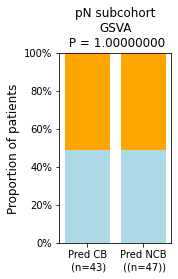

In [100]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import fisher_exact


# Example data
categories = [f'Pred CB\n (n={len(predRcb)+len(predNRncb)})', f'Pred NCB\n ((n={len(predNRcb)+len(predRncb)}))']
group1 = [len(predRcb), len(predNRcb)]
group2 = [len(predNRncb),len(predRncb)]

# Combine the groups into a single array
data = np.array([group1, group2])

# Normalize the data to make it 100% stacked
data_normalized = data / data.sum(axis=0)

# Plot
fig, ax = plt.subplots(figsize=(2, 3.5))

# Bottom stack starts at zero
bottom_stack = np.zeros(len(categories))

# Colors for each group
colors = ['lightblue', 'orange']

# Labels for the legend
group_labels = ['Group 1', 'Group 2']

# Plot each group as a stack
for i in range(data.shape[0]):
    ax.bar(categories, data_normalized[i], bottom=bottom_stack, color=colors[i], label=group_labels[i])
    bottom_stack += data_normalized[i]

table = np.array([group1, group2])
res = fisher_exact(table, alternative='two-sided')
print(res)
# Customize the chart
ax.set_title('pN subcohort\nGSVA\n P = {:.8f}'.format(res.pvalue))
#ax.set_ylabel('Proportion of patients')
ax.set_ylim(0, 1)  # Ensure the y-axis goes from 0 to 1 (100%)
#ax.legend(title='Groups')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))  # Format y-axis as percentages
plt.ylabel('Proportion of patients', fontsize=12)
plt.savefig("GSVA_ML-K10-barplot.svg",dpi=300,bbox_inches='tight')
# Display the chart
plt.show()


In [102]:
# Spot Check Algorithms
# edges_input

df_entropy_input = {}

from sklearn.model_selection import LeaveOneOut
for datetype,dataname in \
    zip([ entropy_input.drop(columns=["KEGG_VALINE_LEUCINE_AND_ISOLEUCINE_BIOSYNTHESIS"]).copy()],\
        ["entropy_input"]):
            
    models = []
    models.append(('LR',LogisticRegression(penalty='l2',  C=1,max_iter=1000, random_state=42,class_weight ='balanced')))
    results = []
    names = []
    for name, model in models:
        # Define leave-one-out cross-validation
        loo = LeaveOneOut()
        for i in range(1,11):
            
            # Create a pipeline
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('feature_selection', SelectKBest(score_func=f_classif, k=i*10)), 
                ('logistic_regression', model)       # Logistic Regression model
        ])
        
            # Evaluate the pipeline with LOOCV
            scores = []
            y_resonse = []
            y_pred_list = []
            for train_index, test_index in loo.split(datetype):
                # Split data into train and test for this fold
                X_train, X_test = datetype.iloc[train_index], datetype.iloc[test_index]
                y_train, y_test = dfcl["Benefit"][train_index], dfcl["Benefit"][test_index]
                
                # Fit the pipeline on the training data
                pipeline.fit(X_train, y_train)

                # Access the SelectKBest step
                select_kbest = pipeline.named_steps['feature_selection']
                # Get the selected features
                selected_mask = select_kbest.get_support()  # Boolean mask
                selected_features = X_train.columns[selected_mask]  # Feature names
                #print("Selected Features:", selected_features)
                
                # View the scores of all features
                feature_scores = select_kbest.scores_  # ANOVA F-values for each feature
                df_entropy_input[test_index[0]] = pd.DataFrame({'Feature': X_train.columns, 'Score': feature_scores})

                
                # Predict on the test data
                y_pred = pipeline.predict(X_test)
                y_resonse.append(y_test)
                y_pred_list.append(y_pred)
                # Store the accuracy for this fold
                scores.append(accuracy_score(y_test, y_pred))  
            #print(scores)
            results.append(sum(scores)/len(scores))
            names.append(name)
            print(name, sum(scores)/len(scores))
        

LR 0.5888888888888889
LR 0.4222222222222222
LR 0.43333333333333335
LR 0.37777777777777777
LR 0.3888888888888889
LR 0.4222222222222222
LR 0.4111111111111111
LR 0.37777777777777777
LR 0.4444444444444444
LR 0.4666666666666667


In [39]:
# Spot Check Algorithms
# edges_input

df_entropy_input = {}

from sklearn.model_selection import LeaveOneOut
for datetype,dataname in \
    zip([ entropy_input.drop(columns=["KEGG_VALINE_LEUCINE_AND_ISOLEUCINE_BIOSYNTHESIS"]).copy()],\
        ["entropy_input"]):
            
    models = []
    models.append(('LR',LogisticRegression(penalty='l2',  C=1,max_iter=1000, random_state=42,class_weight ='balanced')))
    results = []
    names = []
    for name, model in models:
        # Define leave-one-out cross-validation
        loo = LeaveOneOut()
        for i in range(1,2):
            
            # Create a pipeline
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('feature_selection', SelectKBest(score_func=f_classif, k=i*10)), 
                ('logistic_regression', model)       # Logistic Regression model
        ])
        
            # Evaluate the pipeline with LOOCV
            scores = []
            y_resonse = []
            y_pred_list = []
            for train_index, test_index in loo.split(datetype):
                # Split data into train and test for this fold
                X_train, X_test = datetype.iloc[train_index], datetype.iloc[test_index]
                y_train, y_test = dfcl["Benefit"][train_index], dfcl["Benefit"][test_index]
                
                # Fit the pipeline on the training data
                pipeline.fit(X_train, y_train)

                # Access the SelectKBest step
                select_kbest = pipeline.named_steps['feature_selection']
                # Get the selected features
                selected_mask = select_kbest.get_support()  # Boolean mask
                selected_features = X_train.columns[selected_mask]  # Feature names
                #print("Selected Features:", selected_features)
                
                # View the scores of all features
                feature_scores = select_kbest.scores_  # ANOVA F-values for each feature
                df_entropy_input[test_index[0]] = pd.DataFrame({'Feature': X_train.columns, 'Score': feature_scores})

                
                # Predict on the test data
                y_pred = pipeline.predict(X_test)
                y_resonse.append(y_test)
                y_pred_list.append(y_pred)
                # Store the accuracy for this fold
                scores.append(accuracy_score(y_test, y_pred))  
            #print(scores)
            results.append(sum(scores)/len(scores))
            names.append(name)
            print(name, sum(scores)/len(scores))
        

LR 0.5888888888888889


In [40]:
print(len(dfcl["Benefit"][np.array(scores) == 1]))

predC = dfcl["Benefit"][np.array(scores) == 1] 
predRcb = predC[predC =="CB"]
predRncb = predC[predC =="NCB"]
print(len(predRcb))
print(len(predRncb))

print(len(dfcl["Benefit"][np.array(scores) == 0]))
predIC = dfcl["Benefit"][np.array(scores) == 0] 
predNRcb = predIC[predIC =="CB"] # pred == NCB
predNRncb = predIC[predIC =="NCB"] # pred == CB
print(len(predNRcb))
print(len(predNRncb))

53
22
31
37
22
15


SignificanceResult(statistic=2.066666666666667, pvalue=0.13341566254192996)


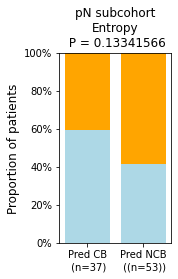

In [103]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import fisher_exact


# Example data
categories = [f'Pred CB\n (n={len(predRcb)+len(predNRncb)})', f'Pred NCB\n ((n={len(predNRcb)+len(predRncb)}))']
group1 = [len(predRcb), len(predNRcb)]
group2 = [len(predNRncb),len(predRncb)]

# Combine the groups into a single array
data = np.array([group1, group2])

# Normalize the data to make it 100% stacked
data_normalized = data / data.sum(axis=0)

# Plot
fig, ax = plt.subplots(figsize=(2, 3.5))

# Bottom stack starts at zero
bottom_stack = np.zeros(len(categories))

# Colors for each group
colors = ['lightblue', 'orange']

# Labels for the legend
group_labels = ['Group 1', 'Group 2']

# Plot each group as a stack
for i in range(data.shape[0]):
    ax.bar(categories, data_normalized[i], bottom=bottom_stack, color=colors[i], label=group_labels[i])
    bottom_stack += data_normalized[i]

table = np.array([group1, group2])
res = fisher_exact(table, alternative='two-sided')
print(res)
# Customize the chart
ax.set_title('pN subcohort\nEntropy\n P = {:.8f}'.format(res.pvalue))
#ax.set_ylabel('Proportion of patients')
ax.set_ylim(0, 1)  # Ensure the y-axis goes from 0 to 1 (100%)
#ax.legend(title='Groups')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))  # Format y-axis as percentages
plt.ylabel('Proportion of patients', fontsize=12)
plt.savefig("ssEntropy_ML-K10-barplot.svg",dpi=300,bbox_inches='tight')
# Display the chart
plt.show()


In [41]:
entropy_input_improved.columns

Index(['KEGG_ABC_TRANSPORTERSgsva', 'KEGG_ACUTE_MYELOID_LEUKEMIAgsva',
       'KEGG_ADHERENS_JUNCTIONgsva',
       'KEGG_ADIPOCYTOKINE_SIGNALING_PATHWAYgsva',
       'KEGG_ALANINE_ASPARTATE_AND_GLUTAMATE_METABOLISMgsva',
       'KEGG_ALDOSTERONE_REGULATED_SODIUM_REABSORPTIONgsva',
       'KEGG_ALLOGRAFT_REJECTIONgsva',
       'KEGG_ALPHA_LINOLENIC_ACID_METABOLISMgsva',
       'KEGG_ALZHEIMERS_DISEASEgsva',
       'KEGG_AMINO_SUGAR_AND_NUCLEOTIDE_SUGAR_METABOLISMgsva',
       ...
       'KEGG_BLADDER_CANCERentropy', 'KEGG_CHRONIC_MYELOID_LEUKEMIAentropy',
       'KEGG_ACUTE_MYELOID_LEUKEMIAentropy',
       'KEGG_SMALL_CELL_LUNG_CANCERentropy',
       'KEGG_NON_SMALL_CELL_LUNG_CANCERentropy', 'KEGG_ASTHMAentropy',
       'KEGG_AUTOIMMUNE_THYROID_DISEASEentropy',
       'KEGG_ALLOGRAFT_REJECTIONentropy',
       'KEGG_GRAFT_VERSUS_HOST_DISEASEentropy',
       'KEGG_VIRAL_MYOCARDITISentropy'],
      dtype='object', length=372)

In [42]:
# Spot Check Algorithms
# edges_input

df_entropy_input_improved = {}

from sklearn.model_selection import LeaveOneOut
for datetype,dataname in \
    zip([ entropy_input_improved.drop(columns=["KEGG_VALINE_LEUCINE_AND_ISOLEUCINE_BIOSYNTHESISentropy"]).copy()],\
        ["entropy_input_improved"]):
            
    models = []
    models.append(('LR',LogisticRegression(penalty='l2',  C=1,max_iter=1000, random_state=42,class_weight ='balanced')))
    results = []
    names = []
    for name, model in models:
        # Define leave-one-out cross-validation
        loo = LeaveOneOut()
        for i in range(1,11):
            
            # Create a pipeline
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('feature_selection', SelectKBest(score_func=f_classif, k=i*10)), 
                ('logistic_regression', model)       # Logistic Regression model
        ])
        
            # Evaluate the pipeline with LOOCV
            scores = []
            y_resonse = []
            y_pred_list = []
            for train_index, test_index in loo.split(datetype):
                # Split data into train and test for this fold
                X_train, X_test = datetype.iloc[train_index], datetype.iloc[test_index]
                y_train, y_test = dfcl["Benefit"][train_index], dfcl["Benefit"][test_index]
                
                # Fit the pipeline on the training data
                pipeline.fit(X_train, y_train)

                # Access the SelectKBest step
                select_kbest = pipeline.named_steps['feature_selection']
                # Get the selected features
                selected_mask = select_kbest.get_support()  # Boolean mask
                selected_features = X_train.columns[selected_mask]  # Feature names
                #print("Selected Features:", selected_features)
                
                # View the scores of all features
                feature_scores = select_kbest.scores_  # ANOVA F-values for each feature
                df_entropy_input_improved[test_index[0]] = pd.DataFrame({'Feature': X_train.columns, 'Score': feature_scores})

                
                # Predict on the test data
                y_pred = pipeline.predict(X_test)
                y_resonse.append(y_test)
                y_pred_list.append(y_pred)
                # Store the accuracy for this fold
                scores.append(accuracy_score(y_test, y_pred))  
            #print(scores)
            results.append(sum(scores)/len(scores))
            names.append(name)
            print(name, sum(scores)/len(scores))
        

LR 0.45555555555555555
LR 0.37777777777777777
LR 0.4444444444444444
LR 0.5111111111111111
LR 0.4222222222222222
LR 0.4222222222222222
LR 0.4111111111111111
LR 0.4111111111111111
LR 0.3888888888888889
LR 0.3333333333333333


In [43]:
# Spot Check Algorithms
# edges_input

df_entropy_input_improved = {}

from sklearn.model_selection import LeaveOneOut
for datetype,dataname in \
    zip([ entropy_input_improved.drop(columns=["KEGG_VALINE_LEUCINE_AND_ISOLEUCINE_BIOSYNTHESISentropy"]).copy()],\
        ["entropy_input_improved"]):
            
    models = []
    models.append(('LR',LogisticRegression(penalty='l2',  C=1,max_iter=1000, random_state=42,class_weight ='balanced')))
    results = []
    names = []
    for name, model in models:
        # Define leave-one-out cross-validation
        loo = LeaveOneOut()
        for i in range(4,5):
            
            # Create a pipeline
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('feature_selection', SelectKBest(score_func=f_classif, k=i*10)), 
                ('logistic_regression', model)       # Logistic Regression model
        ])
        
            # Evaluate the pipeline with LOOCV
            scores = []
            y_resonse = []
            y_pred_list = []
            for train_index, test_index in loo.split(datetype):
                # Split data into train and test for this fold
                X_train, X_test = datetype.iloc[train_index], datetype.iloc[test_index]
                y_train, y_test = dfcl["Benefit"][train_index], dfcl["Benefit"][test_index]
                
                # Fit the pipeline on the training data
                pipeline.fit(X_train, y_train)

                # Access the SelectKBest step
                select_kbest = pipeline.named_steps['feature_selection']
                # Get the selected features
                selected_mask = select_kbest.get_support()  # Boolean mask
                selected_features = X_train.columns[selected_mask]  # Feature names
                #print("Selected Features:", selected_features)
                
                # View the scores of all features
                feature_scores = select_kbest.scores_  # ANOVA F-values for each feature
                df_entropy_input_improved[test_index[0]] = pd.DataFrame({'Feature': X_train.columns, 'Score': feature_scores})

                
                # Predict on the test data
                y_pred = pipeline.predict(X_test)
                y_resonse.append(y_test)
                y_pred_list.append(y_pred)
                # Store the accuracy for this fold
                scores.append(accuracy_score(y_test, y_pred))  
            #print(scores)
            results.append(sum(scores)/len(scores))
            names.append(name)
            print(name, sum(scores)/len(scores))
        

LR 0.5111111111111111


In [44]:
print(len(dfcl["Benefit"][np.array(scores) == 1]))

predC = dfcl["Benefit"][np.array(scores) == 1] 
predRcb = predC[predC =="CB"]
predRncb = predC[predC =="NCB"]
print(len(predRcb))
print(len(predRncb))

print(len(dfcl["Benefit"][np.array(scores) == 0]))
predIC = dfcl["Benefit"][np.array(scores) == 0] 
predNRcb = predIC[predIC =="CB"] # pred == NCB
predNRncb = predIC[predIC =="NCB"] # pred == CB
print(len(predNRcb))
print(len(predNRncb))

46
21
25
44
23
21


SignificanceResult(statistic=1.0869565217391304, pvalue=1.0)


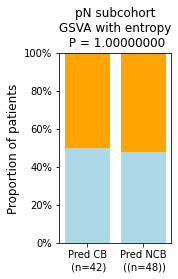

In [45]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import fisher_exact


# Example data
categories = [f'Pred CB\n (n={len(predRcb)+len(predNRncb)})', f'Pred NCB\n ((n={len(predNRcb)+len(predRncb)}))']
group1 = [len(predRcb), len(predNRcb)]
group2 = [len(predNRncb),len(predRncb)]

# Combine the groups into a single array
data = np.array([group1, group2])

# Normalize the data to make it 100% stacked
data_normalized = data / data.sum(axis=0)

# Plot
fig, ax = plt.subplots(figsize=(2, 3.5))

# Bottom stack starts at zero
bottom_stack = np.zeros(len(categories))

# Colors for each group
colors = ['lightblue', 'orange']

# Labels for the legend
group_labels = ['Group 1', 'Group 2']

# Plot each group as a stack
for i in range(data.shape[0]):
    ax.bar(categories, data_normalized[i], bottom=bottom_stack, color=colors[i], label=group_labels[i])
    bottom_stack += data_normalized[i]

table = np.array([group1, group2])
res = fisher_exact(table, alternative='two-sided')
print(res)
# Customize the chart
ax.set_title('pN subcohort\nGSVA with entropy\n P = {:.8f}'.format(res.pvalue))
#ax.set_ylabel('Proportion of patients')
ax.set_ylim(0, 1)  # Ensure the y-axis goes from 0 to 1 (100%)
#ax.legend(title='Groups')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))  # Format y-axis as percentages
plt.ylabel('Proportion of patients', fontsize=12)
plt.savefig("ssEntropy_GSVA_ML-K40-barplot.svg",dpi=300,bbox_inches='tight')
# Display the chart
plt.show()


In [ ]:
df_entropy_input_improved[0].sort_values("Score",ascending=False)['Feature'].tolist()